<a href="https://colab.research.google.com/github/gong509/bda/blob/main/TeamP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 46.7 MB/s eta 0:00:00


--- [1] 데이터 기본 정보 확인 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1211801 entries, 0 to 1211800
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   STCS_DT           1211801 non-null  int64 
 1   DAY_DV_CD_NM      1211801 non-null  object
 2   BIZ_DD_STG_CD_NM  1211801 non-null  object
 3   EXTR_STN_CD       1211801 non-null  int64 
 4   STN_NM            1211801 non-null  object
 5   HR_UNIT_HR_DV_CD  1211801 non-null  int64 
 6   ABRD_PRNB         1211801 non-null  int64 
 7   GOFF_PRNB         1211801 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 74.0+ MB

--- [2] 전처리 완료 후 상위 3개 행 확인 ---


,STCS_DT,DAY_DV_CD_NM,BIZ_DD_STG_CD_NM,EXTR_STN_CD,STN_NM,HR_UNIT_HR_DV_CD,ABRD_PRNB,GOFF_PRNB,TOTAL_PRNB,MONTH
0,2021-01-01,금,공휴일,1001,서울,0,2,2,4,1
1,2021-01-01,금,공휴일,1001,서울,5,1,5,6,1
2,2021-01-01,금,공휴일,1001,서울,6,3,31,34,1



--- [3] 시각화 진행 중... ---


/tmp/ipykernel_4648/2177791026.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stations.index, y=top_stations.values, palette='Blues_r')


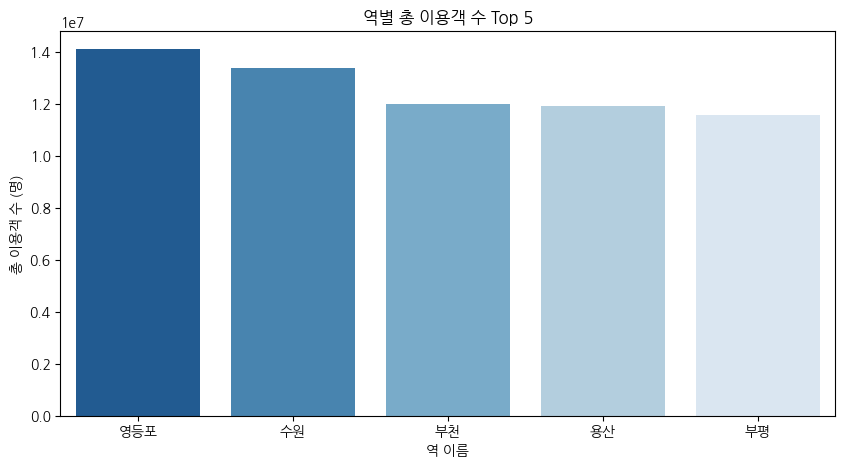

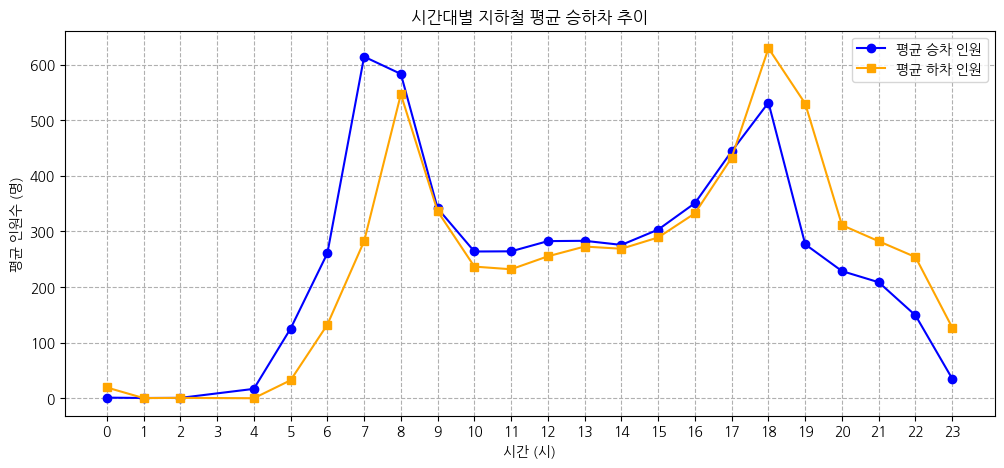

/tmp/ipykernel_4648/2177791026.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_traffic.index, y=weekly_traffic.values, palette='coolwarm')


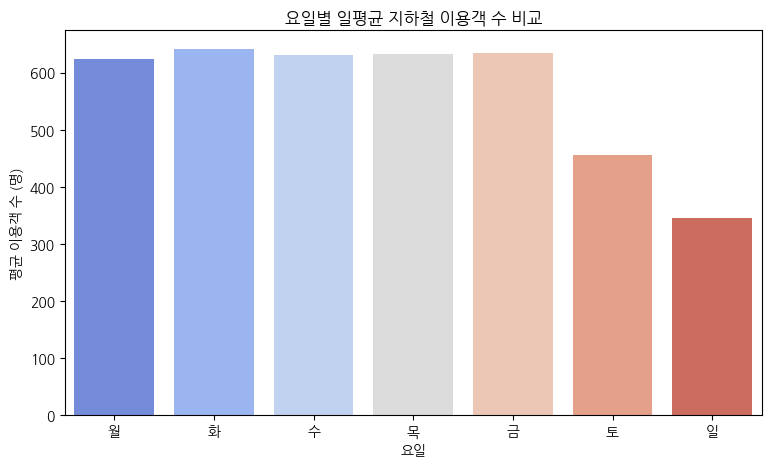

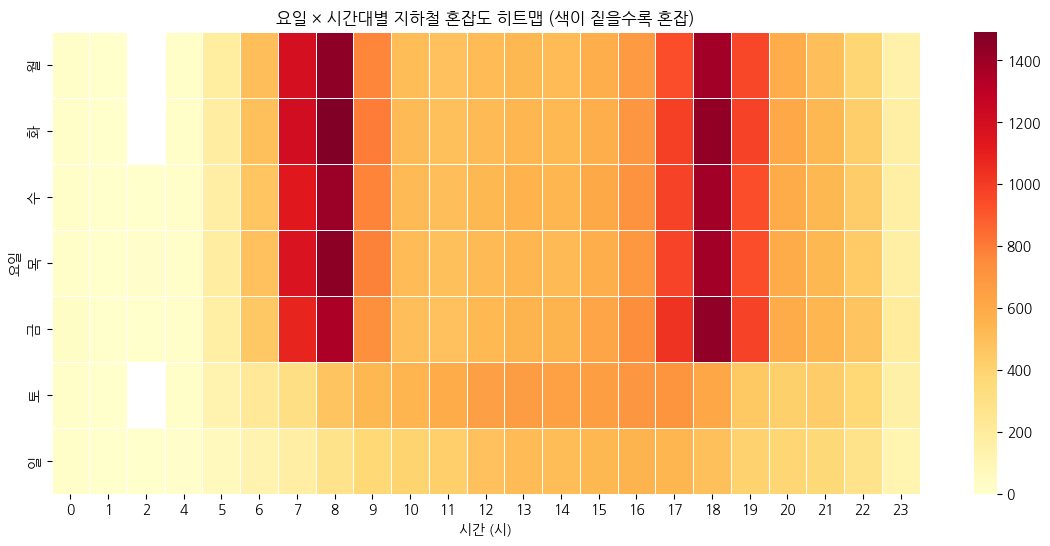


=== [심화] 출근 시간대(07~09시) 하차 비율 상위 5개 역 (오피스/업무 지구) ===


,ABRD_PRNB,GOFF_PRNB,TOTAL,DROP_RATIO
STN_NM,,,,
선릉,106136,1651655,1757791,0.939620
원시,25937,280777,306714,0.915436
압구정로데오,118410,1267077,1385487,0.914535
서울(경의선),48655,471857,520512,0.906525
남동인더스파크,29858,273831,303689,0.901682



=== [심화] 출근 시간대(07~09시) 승차 비율 상위 5개 역 (주거 중심 지출 지구) ===


,ABRD_PRNB,GOFF_PRNB,TOTAL,DROP_RATIO
STN_NM,,,,
강매,270065,39535,309600,0.127697
신이문,619164,118704,737868,0.160874
삼동,197374,38468,235842,0.163109
사리,278328,56956,335284,0.169874
녹천,317726,68001,385727,0.176293


In [1]:
# ==========================================
# 1. 라이브러리 로드 및 한글 설정
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib  # 한글 깨짐 방지 라이브러리

# 주피터 노트북 내 그래프 출력을 위한 설정
%matplotlib inline

# ==========================================
# 2. 데이터 불러오기 및 전처리 (Data Preprocessing)
# ==========================================
# 파일 불러오기 (한글 인코딩 설정)
df = pd.read_csv('TR032000010001.csv', encoding='utf-8')

print("--- [1] 데이터 기본 정보 확인 ---")
df.info()

# 전처리 ①: 날짜 데이터를 파이썬 datetime 형식으로 변환
df['STCS_DT'] = pd.to_datetime(df['STCS_DT'].astype(str), format='%Y%m%d')

# 전처리 ②: 시간대 데이터를 분석 및 정렬이 쉽도록 숫자형(int)으로 변환
df['HR_UNIT_HR_DV_CD'] = df['HR_UNIT_HR_DV_CD'].astype(int)

# 전처리 ③: 파생변수 생성 - 승차와 하차를 더한 '총 이용객수(TOTAL_PRNB)'
df['TOTAL_PRNB'] = df['ABRD_PRNB'] + df['GOFF_PRNB']

# 전처리 ④: 파생변수 생성 - 날짜에서 '월(Month)' 정보 추출
df['MONTH'] = df['STCS_DT'].dt.month

print("\n--- [2] 전처리 완료 후 상위 3개 행 확인 ---")
display(df.head(3))


# ==========================================
# 3. 기본 분석 및 시각화
# ==========================================
print("\n--- [3] 시각화 진행 중... ---")

# --- [기본 분석 ①] 이용객 수가 가장 많은 역 Top 5 ---
top_stations = df.groupby('STN_NM')['TOTAL_PRNB'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_stations.index, y=top_stations.values, palette='Blues_r')
plt.title('역별 총 이용객 수 Top 5')
plt.xlabel('역 이름')
plt.ylabel('총 이용객 수 (명)')
plt.show()

# --- [기본 분석 ②] 시간대별 지하철 승하차 추이 (전체 평균) ---
hourly_traffic = df.groupby('HR_UNIT_HR_DV_CD')[['ABRD_PRNB', 'GOFF_PRNB']].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_traffic.index, hourly_traffic['ABRD_PRNB'], marker='o', label='평균 승차 인원', color='blue')
plt.plot(hourly_traffic.index, hourly_traffic['GOFF_PRNB'], marker='s', label='평균 하차 인원', color='orange')
plt.title('시간대별 지하철 평균 승하차 추이')
plt.xlabel('시간 (시)')
plt.ylabel('평균 인원수 (명)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


# ==========================================
# 4. 심화 추가 활동 (차별화 포인트)
# ==========================================

# --- [추가 활동 ①] 요일별 지하철 이용객 분포 분석 ---
# 요일이 제각각 섞이지 않도록 월~일 순서 정의
weekday_order = ['월', '화', '수', '목', '금', '토', '일']
weekly_traffic = df.groupby('DAY_DV_CD_NM')['TOTAL_PRNB'].mean().reindex(weekday_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=weekly_traffic.index, y=weekly_traffic.values, palette='coolwarm')
plt.title('요일별 일평균 지하철 이용객 수 비교')
plt.xlabel('요일')
plt.ylabel('평균 이용객 수 (명)')
plt.show()


# --- [추가 활동 ②] 피벗 테이블을 활용한 요일 × 시간대별 혼잡도 히트맵 ---
# 요일과 시간대를 축으로 하는 평균 이용객 피벗 테이블 생성
pivot_df = df.pivot_table(index='DAY_DV_CD_NM', columns='HR_UNIT_HR_DV_CD', values='TOTAL_PRNB', aggfunc='mean')
pivot_df = pivot_df.reindex(weekday_order)

plt.figure(figsize=(14, 6))
# 부드럽고 직관적인 붉은색 계열(YlOrRd)로 혼잡도 표현
sns.heatmap(pivot_df, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('요일 × 시간대별 지하철 혼잡도 히트맵 (색이 짙을수록 혼잡)')
plt.xlabel('시간 (시)')
plt.ylabel('요일')
plt.show()


# --- [추가 활동 ③] 출근 시간대(7시~9시) 역별 성격 분석 (오피스 vs 주거) ---
# 출근 시간대 데이터만 필터링
rush_hour = df[df['HR_UNIT_HR_DV_CD'].isin([7, 8, 9])]

# 역별 출근 시간대 승하차 총합 계산
rush_station = rush_hour.groupby('STN_NM')[['ABRD_PRNB', 'GOFF_PRNB']].sum()

# 총 승하차 인원이 너무 적은 역은 제외하기 위해 기준 설정 (예: 총합 1000명 이상인 역만)
rush_station['TOTAL'] = rush_station['ABRD_PRNB'] + rush_station['GOFF_PRNB']
rush_station = rush_station[rush_station['TOTAL'] >= 1000]

# 하차 비율 계산 (출근 시간대에 내리는 사람이 많을수록 일자리가 많은 오피스 지역)
rush_station['DROP_RATIO'] = rush_station['GOFF_PRNB'] / rush_station['TOTAL']

print("\n=== [심화] 출근 시간대(07~09시) 하차 비율 상위 5개 역 (오피스/업무 지구) ===")
display(rush_station.sort_values(by='DROP_RATIO', ascending=False).head(5))

print("\n=== [심화] 출근 시간대(07~09시) 승차 비율 상위 5개 역 (주거 중심 지출 지구) ===")
display(rush_station.sort_values(by='DROP_RATIO', ascending=True).head(5))

## 결론 및 인사이트 요약

1. **데이터 전처리 요과**: 문자열로 구성된 시간대 데이터를 숫자형으로 변환하여 연속적인 시간 축 그래프 시각화를 매끄럽게 처리하였으며, 승/하차 인원을 통합한 `TOTAL_PRNB` 파생변수를 통해 종합 유동인구를 쉽게 분석할 수 있었다.
2. **이용 패턴 분석**: 하루 중 지하철 이용객은 전형적인 출근 시간(08시)과 퇴근 시간(18시)에 정점을 찍는 '쌍봉형(Double Peak)' 패턴을 보였다.
3. **요일별 혼잡도**: 히트맵 분석 결과, 주말보다는 평일(월~금)의 출퇴근 시간대에 혼잡도가 집중되는 양상을 보였으며, 주말의 경우 혼잡도가 낮고 오후 시간대에 완만하게 분산되는 특징을 확인했다.
4. **역별 공간적 특성**: 출근 시간대 승하차 비율 분석을 통해, 특정 역들은 아침 시간에 하차 인원이 압도적으로 많은 '오피스/업무 중심 지역'의 특성을 띄는 반면, 어떤 역들은 승차 인원이 많아 출근 시 승객이 빠져나가는 '주거 중심 지역(배드타운)'의 특성을 명확히 보여주었다.